### Phương pháp 1 dùng gói thư viện Apriori

#### Nhập thư viện 

In [157]:
import pandas as pd
import numpy as np
from apyori import apriori
import matplotlib.pyplot as plt

#### Tải dữ liệu 

In [158]:
df = pd.read_csv("Market_Basket_Optimisation.csv",header = None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Làm sạch dữ liệu 
+ thay những dòng bị thiếu với giá trị 0 

In [159]:
df.fillna(0,inplace=True)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,chutney,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,turkey,avocado,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,mineral water,milk,energy bar,whole wheat rice,green tea,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


#### Tiền xử lý dữ liệu 
+ Sử dụng thư viện Apriori 
+ Chuyển dữ liệu sang dạng list
+ transaction = [['apple','almonds'],['apple'],['banana','apple']]....

In [160]:
transactions = []

for i in range(0,len(df)):
    transactions.append([str(df.values[i,j]) for j in range(0,20) if str(df.values[i,j])!='0'])

#### Xác nhận bằng cách in dòng thứ 0 

In [161]:
transactions[0]

['shrimp',
 'almonds',
 'avocado',
 'vegetables mix',
 'green grapes',
 'whole weat flour',
 'yams',
 'cottage cheese',
 'energy drink',
 'tomato juice',
 'low fat yogurt',
 'green tea',
 'honey',
 'salad',
 'mineral water',
 'salmon',
 'antioxydant juice',
 'frozen smoothie',
 'spinach',
 'olive oil']

#### Xác nhận bằng cách in dòng thứ 1 

In [162]:
## verifying - by printing the 1st transaction
transactions[1]

['burgers', 'meatballs', 'eggs']

#### Gọi hàm Apriori, trong đó ta cần truyền vào các tham số tối thiểu như:
+ minimum support,
+ confidence,
+ lift,
+ minimum length (độ dài tối thiểu của tập các mặt hàng – mặc định là 2).
+ min_support = 0.003 → nghĩa là chọn các mục có độ hỗ trợ tối thiểu 0.3%
+ min_confidence = 0.2 → nghĩa là độ tin cậy tối thiểu 20%
+ min_lift = 3
+ min_length = 2 → nghĩa là mỗi luật kết hợp phải có ít nhất 2 sản phẩm trong giao dịch

In [163]:
rules = apriori(transactions, min_support=0.003, min_confidence=0.2, min_lift=3, min_length=2)

In [164]:
# Khởi tạo các luật trong file 
rules

<generator object apriori at 0x000001DC38306260>

In [165]:
# Đưa tất cả luật chuyển sang list
Results = list(rules)
Results

[RelationRecord(items=frozenset({'light cream', 'chicken'}), support=0.004532728969470737, ordered_statistics=[OrderedStatistic(items_base=frozenset({'light cream'}), items_add=frozenset({'chicken'}), confidence=0.29059829059829057, lift=4.84395061728395)]),
 RelationRecord(items=frozenset({'mushroom cream sauce', 'escalope'}), support=0.005732568990801226, ordered_statistics=[OrderedStatistic(items_base=frozenset({'mushroom cream sauce'}), items_add=frozenset({'escalope'}), confidence=0.3006993006993007, lift=3.790832696715049)]),
 RelationRecord(items=frozenset({'pasta', 'escalope'}), support=0.005865884548726837, ordered_statistics=[OrderedStatistic(items_base=frozenset({'pasta'}), items_add=frozenset({'escalope'}), confidence=0.3728813559322034, lift=4.700811850163794)]),
 RelationRecord(items=frozenset({'honey', 'fromage blanc'}), support=0.003332888948140248, ordered_statistics=[OrderedStatistic(items_base=frozenset({'fromage blanc'}), items_add=frozenset({'honey'}), confidence=0

In [166]:
# Chuyển result sang dạng DataFrame order_statistics(thống kê theo thứ tự luật) là một danh sách, nên cần phải được chuyển đổi về đúng định dạng.
df_results = pd.DataFrame(Results)
df_results.head()

,items,support,ordered_statistics
0,"(light cream, chicken)",0.004533,"[((light cream), (chicken), 0.2905982905982905..."
1,"(mushroom cream sauce, escalope)",0.005733,"[((mushroom cream sauce), (escalope), 0.300699..."
2,"(pasta, escalope)",0.005866,"[((pasta), (escalope), 0.3728813559322034, 4.7..."
3,"(honey, fromage blanc)",0.003333,"[((fromage blanc), (honey), 0.2450980392156863..."
4,"(ground beef, herb & pepper)",0.015998,"[((herb & pepper), (ground beef), 0.3234501347..."


In [167]:
# Tạo bản sao chô chỉ số Support 
support = df_results.support

In [168]:
'''
chuyển đổi order_statistic về đúng định dạng.
order_statistic có cả dạng luật từ trái sang phải (lhs → rhs) và ngược lại (rhs → lhs).
chúng ta có thể chọn một trong hai tùy theo sự thuận tiện.
Hãy chọn dạng thứ nhất, chính là df_results['ordered_statistics'][i][0].
''' 

# bốn danh sách rỗng này sẽ lần lượt chứa: lhs (vế trái), rhs (vế phải), confidence và lift.
first_values = []
second_values = []
third_values = []
fourth_value = []

# lặp qua số dòng và thêm từng giá trị vào danh sách tương ứng.
# phần tử thứ 1 và thứ 2 là frozenset, nên cần chuyển về dạng list.
for i in range(df_results.shape[0]):
    single_list = df_results['ordered_statistics'][i][0]
    first_values.append(list(single_list[0]))
    second_values.append(list(single_list[1]))
    third_values.append(single_list[2])
    fourth_value.append(single_list[3])

In [169]:
# Chuyển cả bốn list thành DataFrame 
lhs = pd.DataFrame(first_values)
rhs = pd.DataFrame(second_values)

confidence=pd.DataFrame(third_values,columns=['Confidence'])

lift=pd.DataFrame(fourth_value,columns=['lift'])

In [170]:
# Ghép các DataFrame lại thành 1 Dataframe duy nhất
df_final = pd.concat([lhs,rhs,support,confidence,lift], axis=1)
df_final


,0,1,2,0,1,support,Confidence,lift
0,light cream,None,None,chicken,None,0.004533,0.290598,4.843951
1,mushroom cream sauce,None,None,escalope,None,0.005733,0.300699,3.790833
2,pasta,None,None,escalope,None,0.005866,0.372881,4.700812
3,fromage blanc,None,None,honey,None,0.003333,0.245098,5.164271
4,herb & pepper,None,None,ground beef,None,0.015998,0.323450,3.291994
...,...,...,...,...,...,...,...,...
75,ground beef,olive oil,None,mineral water,spaghetti,0.003066,0.216981,3.632981
76,ground beef,pancakes,None,mineral water,spaghetti,0.003066,0.211009,3.532991
77,ground beef,tomatoes,None,mineral water,spaghetti,0.003066,0.261364,4.376091
78,mineral water,spaghetti,milk,olive oil,None,0.003333,0.211864,3.216994


In [171]:
'''
 Ở một số dòng, vế trái (lhs) chỉ có 1 mục, nhưng ở những dòng khác lại có 3 mục hoặc nhiều hơn, nên chúng ta cần có cách biểu diễn phù hợp để người dùng dễ hiểu.
 thay thế giá trị None bằng khoảng trắng ' ' và gộp 3 cột thành 1 cột duy nhất.
 “coffee, None, None” sẽ được chuyển thành “coffee, , ”
'''
df_final.fillna(value=' ', inplace=True)
df_final.head()

,0,1,2,0,1,support,Confidence,lift
0,light cream,,,chicken,,0.004533,0.290598,4.843951
1,mushroom cream sauce,,,escalope,,0.005733,0.300699,3.790833
2,pasta,,,escalope,,0.005866,0.372881,4.700812
3,fromage blanc,,,honey,,0.003333,0.245098,5.164271
4,herb & pepper,,,ground beef,,0.015998,0.323450,3.291994


In [172]:
# Đặt tên Cột 
df_final.columns = ['lhs',1,'rhs',2,3,'support','confidence','lift']
df_final.head()

,lhs,1,rhs,2,3,support,confidence,lift
0,light cream,,,chicken,,0.004533,0.290598,4.843951
1,mushroom cream sauce,,,escalope,,0.005733,0.300699,3.790833
2,pasta,,,escalope,,0.005866,0.372881,4.700812
3,fromage blanc,,,honey,,0.003333,0.245098,5.164271
4,herb & pepper,,,ground beef,,0.015998,0.323450,3.291994


In [173]:
# thêm cả ba cột vào tập mục của vế trái (lhs)
df_final['lhs'] = df_final['lhs'] + str(", ") + df_final[1]

df_final['rhs'] = df_final['rhs']+str(", ")+df_final[2] + str(", ") + df_final[3]
df_final.head()

,lhs,1,rhs,2,3,support,confidence,lift
0,"light cream,",,", chicken,",chicken,,0.004533,0.290598,4.843951
1,"mushroom cream sauce,",,", escalope,",escalope,,0.005733,0.300699,3.790833
2,"pasta,",,", escalope,",escalope,,0.005866,0.372881,4.700812
3,"fromage blanc,",,", honey,",honey,,0.003333,0.245098,5.164271
4,"herb & pepper,",,", ground beef,",ground beef,,0.015998,0.323450,3.291994


In [174]:
# xóa các cột 1, 2 và 3 vì chúng đã được ghép vào cột lhs rồi
df_final.drop(columns=[1,2,3],inplace=True)

In [175]:
# Đây là sản phẩm cuối cùng ta có thể phân loại theo  support lift và confidence ..
df_final.head()

,lhs,rhs,support,confidence,lift
0,"light cream,",", chicken,",0.004533,0.290598,4.843951
1,"mushroom cream sauce,",", escalope,",0.005733,0.300699,3.790833
2,"pasta,",", escalope,",0.005866,0.372881,4.700812
3,"fromage blanc,",", honey,",0.003333,0.245098,5.164271
4,"herb & pepper,",", ground beef,",0.015998,0.323450,3.291994


In [176]:
# Hiển thị 10 luật có giá trị lift cao nhất. Sắp xếp theo thứ tự giảm dần.
df_final.sort_values('lift', ascending=False).head(10)

,lhs,rhs,support,confidence,lift
70,"soup, frozen vegetables",", mineral water, milk",0.003066,0.383333,7.987176
69,"olive oil, frozen vegetables",", mineral water, milk",0.003333,0.294118,6.128268
52,"mineral water, whole wheat pasta",", olive oil,",0.003866,0.402778,6.115863
44,"tomato sauce,",", ground beef, spaghetti",0.003066,0.216981,5.535971
3,"fromage blanc,",", honey,",0.003333,0.245098,5.164271
0,"light cream,",", chicken,",0.004533,0.290598,4.843951
2,"pasta,",", escalope,",0.005866,0.372881,4.700812
24,"ground beef, french fries",", herb & pepper,",0.003200,0.230769,4.665768
61,"frozen vegetables, mineral water","chocolate, shrimp,",0.003200,0.328767,4.600900
66,"ground beef, frozen vegetables",", mineral water, milk",0.003733,0.220472,4.593788


### Sắp xếp và hiển thị các luật mạnh 

In [177]:
# Sắp xếp theo lift giảm dần
df_final.sort_values(by='lift', ascending=False).head(20)


,lhs,rhs,support,confidence,lift
70,"soup, frozen vegetables",", mineral water, milk",0.003066,0.383333,7.987176
69,"olive oil, frozen vegetables",", mineral water, milk",0.003333,0.294118,6.128268
52,"mineral water, whole wheat pasta",", olive oil,",0.003866,0.402778,6.115863
44,"tomato sauce,",", ground beef, spaghetti",0.003066,0.216981,5.535971
3,"fromage blanc,",", honey,",0.003333,0.245098,5.164271
0,"light cream,",", chicken,",0.004533,0.290598,4.843951
2,"pasta,",", escalope,",0.005866,0.372881,4.700812
24,"ground beef, french fries",", herb & pepper,",0.003200,0.230769,4.665768
61,"frozen vegetables, mineral water","chocolate, shrimp,",0.003200,0.328767,4.600900
66,"ground beef, frozen vegetables",", mineral water, milk",0.003733,0.220472,4.593788


In [178]:
df_final.sort_values(by='confidence', ascending=False).head(20)

,lhs,rhs,support,confidence,lift
14,"ground beef, cereals",", spaghetti,",0.003066,0.676471,3.885303
54,"tomatoes, olive oil",", spaghetti,",0.004399,0.611111,3.509912
21,"ground beef, cooking oil",", spaghetti,",0.004799,0.571429,3.281995
58,"frozen vegetables, ground beef","chocolate, spaghetti,",0.003066,0.534884,3.072100
67,"ground beef, milk","frozen vegetables, spaghetti,",0.003066,0.534884,3.072100
23,"red wine, eggs",", spaghetti,",0.003733,0.528302,3.034297
43,"ground beef, shrimp",", spaghetti,",0.005999,0.523256,3.005315
28,"soup, frozen vegetables",", milk,",0.003999,0.500000,3.858539
50,"spaghetti, whole wheat pasta",", milk,",0.003999,0.454545,3.507763
19,"herb & pepper, chocolate",", ground beef,",0.003999,0.441176,4.490183


### Phương pháp 2 dùng thư viện Apriori
+ sử dụng gói mlxtend.frequent_patterns.”

In [179]:
'''
tải (import) các module apriori và association_rules từ mlxtend.frequent_patterns
sử dụng một dataset khác vì mlxtend yêu cầu dữ liệu phải có dạng như dưới đây: 
mỗi giao dịch là một dòng, mỗi sản phẩm là một cột, và giá trị là 0/1 (không mua / có mua).
    transaction_name    apple banana grapes
transaction  1            0     1      1
             2            1     0      1  
             3            1     0      0
             4            0     1      0
             
 chúng ta có thể dùng dataset ở trên, nhưng phải xử lý lại khá nhiều để đưa về đúng định dạng 0/1 này — thay vì làm vậy, ở đây dùng một dataset khác cho thuận tiện.           
'''

import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

df1 = pd.read_csv('data-2.csv', encoding="ISO-8859-1")
df1.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [180]:
# dataset có nhiều quốc gia, nên chọn một quốc gia bất kỳ để kiểm tra.
df1.Country.value_counts().head(5)


Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Name: count, dtype: int64

In [181]:
# tạm thời chỉ sử dụng dữ liệu của quốc gia France; bạn cũng có thể kiểm tra cho các quốc gia khác.
df1 = df1[df1.Country == 'France']

In [182]:
# trong cột Description có một số khoảng trắng (space); cần xóa chúng, nếu không sẽ gây lỗi ở các bước xử lý tiếp theo.
df1['Description'] = df1['Description'].str.strip()

In [183]:
# một số giao dịch có số lượng (Quantity) âm, điều này là không hợp lý nên cần loại bỏ các dòng đó.
df1 = df1[df1.Quantity >0]
df1.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,12/1/2010 8:45,3.75,12583.0,France
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,12/1/2010 8:45,3.75,12583.0,France
28,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,12/1/2010 8:45,3.75,12583.0,France
29,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,12/1/2010 8:45,0.85,12583.0,France
30,536370,21883,STARS GIFT TAPE,24,12/1/2010 8:45,0.65,12583.0,France
31,536370,10002,INFLATABLE POLITICAL GLOBE,48,12/1/2010 8:45,0.85,12583.0,France
32,536370,21791,VINTAGE HEADS AND TAILS CARD GAME,24,12/1/2010 8:45,1.25,12583.0,France
33,536370,21035,SET/2 RED RETROSPOT TEA TOWELS,18,12/1/2010 8:45,2.95,12583.0,France
34,536370,22326,ROUND SNACK BOXES SET OF4 WOODLAND,24,12/1/2010 8:45,2.95,12583.0,France
35,536370,22629,SPACEBOY LUNCH BOX,24,12/1/2010 8:45,1.95,12583.0,France


In [184]:
# chuyển dữ liệu về đúng định dạng mà thuật toán yêu cầu
# chuyển đổi bằng pivot table, dùng tổng Quantity làm giá trị. Nếu có giá trị NaN thì thay bằng 0.

basket = pd.pivot_table(data=df1,index='InvoiceNo',columns='Description',values='Quantity', aggfunc='sum',fill_value=0)
basket.head()

Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 EGG HOUSE PAINTED WOOD,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE POSY,12 PENCILS TALL TUBE RED RETROSPOT,12 PENCILS TALL TUBE WOODLAND,...,WRAP VINTAGE PETALS DESIGN,YELLOW COAT RACK PARIS FASHION,YELLOW GIANT GARDEN THERMOMETER,YELLOW SHARK HELICOPTER,ZINC STAR T-LIGHT HOLDER,ZINC FOLKART SLEIGH BELLS,ZINC HERB GARDEN CONTAINER,ZINC METAL HEART DECORATION,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536370,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536852,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536974,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
537065,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
537463,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [185]:
# dòng này dùng để kiểm tra xem dữ liệu sau khi chuyển đổi (binning thành 1) có đúng hay không. 
basket['10 COLOUR SPACEBOY PEN'].head(10)

InvoiceNo
536370     0
536852     0
536974     0
537065     0
537463     0
537468    24
537693     0
537897     0
537967     0
538008     0
Name: 10 COLOUR SPACEBOY PEN, dtype: int64

In [186]:
# chúng ta không cần tổng số lượng sản phẩm.
# chúng ta chỉ cần biết khách hàng có mua sản phẩm đó hay không.
# vì vậy, nếu khách hàng mua sản phẩm thì đánh dấu 1, còn không mua thì đánh dấu 0.

def convert_into_binary(x):
    if x > 0:
        return 1
    else:
        return 0

In [187]:
basket_sets = basket.applymap(convert_into_binary)

C:\Users\dvt\AppData\Local\Temp\ipykernel_15848\3155827604.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = basket.applymap(convert_into_binary)


In [188]:
# Kiểm tra: số lượng bây giờ đã được chuyển thành 1 hoặc 0.
basket_sets['10 COLOUR SPACEBOY PEN'].head(10)

InvoiceNo
536370    0
536852    0
536974    0
537065    0
537463    0
537468    1
537693    0
537897    0
537967    0
538008    0
Name: 10 COLOUR SPACEBOY PEN, dtype: int64

In [189]:
# Loại bỏ mặt hàng "POSTAGE" vì nó chỉ là phí vận chuyển, hầu như giao dịch nào cũng có.
print(basket_sets['POSTAGE'].head())

basket_sets.drop(columns=['POSTAGE'],inplace=True)

InvoiceNo
536370    1
536852    1
536974    1
537065    1
537463    1
Name: POSTAGE, dtype: int64


In [190]:
# Gọi hàm apriori và truyền vào giá trị min_support — ở đây ta chọn mức 7%.
# Nghĩa là một mặt hàng phải xuất hiện trong ít nhất 7% tổng số giao dịch.
frequent_itemsets = apriori(basket_sets, min_support=0.07, use_colnames=True)

c:\Users\dvt\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [191]:
# Dòng này sẽ tạo ra (hoặc hiển thị) tập các itemset thường xuyên.
frequent_itemsets

,support,itemsets
0,0.071429,(4 TRADITIONAL SPINNING TOPS)
1,0.096939,(ALARM CLOCK BAKELIKE GREEN)
2,0.102041,(ALARM CLOCK BAKELIKE PINK)
3,0.094388,(ALARM CLOCK BAKELIKE RED)
4,0.081633,(BAKING SET 9 PIECE RETROSPOT)
5,0.071429,(CHILDRENS CUTLERY DOLLY GIRL)
6,0.099490,(DOLLY GIRL LUNCH BOX)
7,0.096939,(JUMBO BAG RED RETROSPOT)
8,0.076531,(JUMBO BAG WOODLAND ANIMALS)
9,0.125000,(LUNCH BAG APPLE DESIGN)


In [192]:
# Tạo luật kết hợp 
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
rules.head()


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE GREEN),0.102041,0.096939,0.073980,0.725000,7.478947,1.0,0.064088,3.283859,0.964734,0.591837,0.695480,0.744079
1,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE PINK),0.096939,0.102041,0.073980,0.763158,7.478947,1.0,0.064088,3.791383,0.959283,0.591837,0.736244,0.744079
2,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED),0.096939,0.094388,0.079082,0.815789,8.642959,1.0,0.069932,4.916181,0.979224,0.704545,0.796590,0.826814
3,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE GREEN),0.094388,0.096939,0.079082,0.837838,8.642959,1.0,0.069932,5.568878,0.976465,0.704545,0.820431,0.826814
4,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE RED),0.102041,0.094388,0.073980,0.725000,7.681081,1.0,0.064348,3.293135,0.968652,0.604167,0.696338,0.754392


In [193]:
### Lọc luật mạnh với confidence >= 0.7 
rules_strong = rules[rules['confidence'] >= 0.7]
rules_strong.sort_values(by='lift', ascending=False).head(20)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE GREEN),0.094388,0.096939,0.079082,0.837838,8.642959,1.0,0.069932,5.568878,0.976465,0.704545,0.820431,0.826814
2,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED),0.096939,0.094388,0.079082,0.815789,8.642959,1.0,0.069932,4.916181,0.979224,0.704545,0.796590,0.826814
5,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE PINK),0.094388,0.102041,0.073980,0.783784,7.681081,1.0,0.064348,4.153061,0.960466,0.604167,0.759214,0.754392
4,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE RED),0.102041,0.094388,0.073980,0.725000,7.681081,1.0,0.064348,3.293135,0.968652,0.604167,0.696338,0.754392
24,(SET/6 RED SPOTTY PAPER PLATES),"(SET/20 RED RETROSPOT PAPER NAPKINS, SET/6 RED...",0.127551,0.102041,0.099490,0.780000,7.644000,1.0,0.086474,4.081633,0.996251,0.764706,0.755000,0.877500
21,"(SET/20 RED RETROSPOT PAPER NAPKINS, SET/6 RED...",(SET/6 RED SPOTTY PAPER PLATES),0.102041,0.127551,0.099490,0.975000,7.644000,1.0,0.086474,34.897959,0.967949,0.764706,0.971345,0.877500
0,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE GREEN),0.102041,0.096939,0.073980,0.725000,7.478947,1.0,0.064088,3.283859,0.964734,0.591837,0.695480,0.744079
1,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE PINK),0.096939,0.102041,0.073980,0.763158,7.478947,1.0,0.064088,3.791383,0.959283,0.591837,0.736244,0.744079
20,"(SET/20 RED RETROSPOT PAPER NAPKINS, SET/6 RED...",(SET/6 RED SPOTTY PAPER CUPS),0.102041,0.137755,0.099490,0.975000,7.077778,1.0,0.085433,34.489796,0.956294,0.709091,0.971006,0.848611
25,(SET/6 RED SPOTTY PAPER CUPS),"(SET/20 RED RETROSPOT PAPER NAPKINS, SET/6 RED...",0.137755,0.102041,0.099490,0.722222,7.077778,1.0,0.085433,3.232653,0.995904,0.709091,0.690657,0.848611


In [194]:
# Sắp xếp giảm dần theo confidence
top5_confidence = rules.sort_values(by='confidence', ascending=False).head(5)

# Hiển thị gọn gàng hơn
top5_confidence[['antecedents', 'consequents', 'support', 'confidence', 'lift']]


,antecedents,consequents,support,confidence,lift
21,"(SET/20 RED RETROSPOT PAPER NAPKINS, SET/6 RED...",(SET/6 RED SPOTTY PAPER PLATES),0.099490,0.975000,7.644000
20,"(SET/20 RED RETROSPOT PAPER NAPKINS, SET/6 RED...",(SET/6 RED SPOTTY PAPER CUPS),0.099490,0.975000,7.077778
18,(SET/6 RED SPOTTY PAPER PLATES),(SET/6 RED SPOTTY PAPER CUPS),0.122449,0.960000,6.968889
19,(SET/6 RED SPOTTY PAPER CUPS),(SET/6 RED SPOTTY PAPER PLATES),0.122449,0.888889,6.968889
3,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE GREEN),0.079082,0.837838,8.642959


In [195]:
# Sao chép để không sửa rules gốc
top5_display = top5_confidence.copy()

# Chuyển frozenset -> chuỗi tên sản phẩm
top5_display['antecedents'] = top5_display['antecedents'].apply(lambda x: ', '.join(list(x)))
top5_display['consequents'] = top5_display['consequents'].apply(lambda x: ', '.join(list(x)))

# Hiển thị bảng 5 luật
top5_display[['antecedents', 'consequents', 'support', 'confidence', 'lift']]


,antecedents,consequents,support,confidence,lift
21,"SET/20 RED RETROSPOT PAPER NAPKINS, SET/6 RED ...",SET/6 RED SPOTTY PAPER PLATES,0.099490,0.975000,7.644000
20,"SET/20 RED RETROSPOT PAPER NAPKINS, SET/6 RED ...",SET/6 RED SPOTTY PAPER CUPS,0.099490,0.975000,7.077778
18,SET/6 RED SPOTTY PAPER PLATES,SET/6 RED SPOTTY PAPER CUPS,0.122449,0.960000,6.968889
19,SET/6 RED SPOTTY PAPER CUPS,SET/6 RED SPOTTY PAPER PLATES,0.122449,0.888889,6.968889
3,ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE GREEN,0.079082,0.837838,8.642959


#### Hình vẽ cho thấy mối quan hệ giữa support, confidence của luật

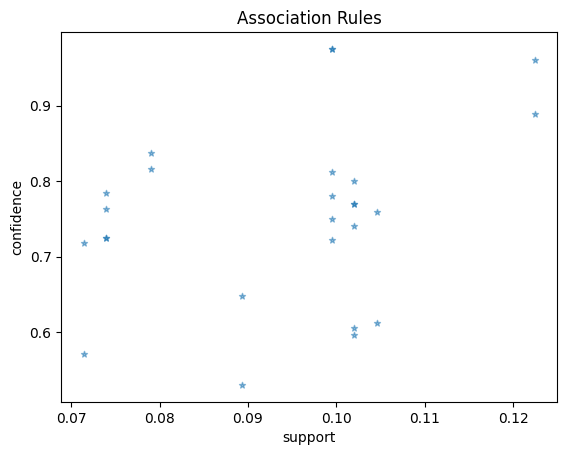

In [196]:
rules.plot.scatter("support", "confidence", alpha=0.5, marker="*")
plt.xlabel("support")
plt.ylabel("confidence")
plt.title("Association Rules")
plt.show()

####  Hình vẽ cho thấy mối quan hệ giữa số item và confidence của luật

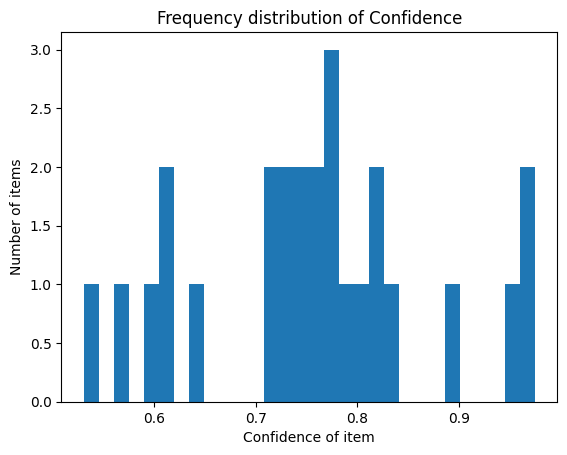

In [197]:
rules.hist("confidence", grid=False, bins=30)
plt.xlabel("Confidence of item")
plt.ylabel("Number of items")
plt.title("Frequency distribution of Confidence")
plt.show()


### Kết thúc 